<a href="https://colab.research.google.com/github/PHYS-3510-SPRING-2026/finding-zeros-lorenzogenera/blob/main/3_23_lecture_finding_0s.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def bisection(f, a, b, dx=1e-10):
    """
    Find a root of f in the bracket [a, b] to within tolerance dx.
    Requires f(a) and f(b) to have opposite signs.
    """
    while (b - a) > dx:                      # keep looping while bracket is wider than dx
        m = (a+b)/2                     # midpoint of current bracket
        if f(m) * f(a) > 0:
            a = m                 # f(m) same sign as f(a): root is in [m, b]
        else:
            b = m                 # f(m) opposite sign to f(a): root is in [a, m]
    return (a+b)/2

/tmp/ipykernel_457/2845111309.py:17: RuntimeWarning: invalid value encountered in log
  return (R_target / xvel0) * (zvel0 + g/b) + (g/b**2) * np.log(1 - b*R_target/xvel0)


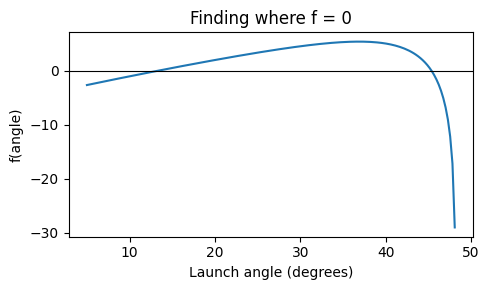

In [ ]:
g = 10       # m/s^2
b = 1        # drag coefficient, 1/s
v0 = 30   # launch speed, m/s
R_target = 20  # desired range, m

def f(angle_deg):
    angle = angle_deg / 180 * np.pi
    xvel0 = v0* np.cos(angle)             # hint: v0 * cos(angle)
    zvel0 = v0 * np.sin(angle) #wrong                     # hint: v0 * sin(angle)
    return (R_target / xvel0) * (zvel0 + g/b) + (g/b**2) * np.log(1 - b*R_target/xvel0)                     # hint: plug xvel0, zvel0, R_target into the equation above

#implement transcentendla
def f(angle_deg):
    angle = angle_deg / 180 * np.pi
    xvel0 = v0 * np.cos(angle)
    zvel0 = v0 * np.sin(angle)
    return (R_target / xvel0) * (zvel0 + g/b) + (g/b**2) * np.log(1 - b*R_target/xvel0)

# Plot f(theta) to choose a good bracket
angles = np.linspace(5, 85, 300)
fig, ax = plt.subplots(1, figsize=(5, 3))
ax.plot(angles, [f(a) for a in angles])
ax.axhline(0, color='k', linewidth=0.8)
ax.set_xlabel('Launch angle (degrees)')
ax.set_ylabel('f(angle)')
ax.set_title('Finding where f = 0')
plt.tight_layout()
plt.show()

In [ ]:
result = bisection(f, 5, 20, dx=1e-3)   # choose a bracket based on the plot above
print(f'Launch angle: {result:.3f} degrees')

result = bisection(f, 40, 60, dx=1e-3)   # choose a bracket based on the plot above
print(f'Launch angle: {result:.3f} degrees')

result = bisection(f, 2, 89, dx=1e-3)   # choose a bracket based on the plot above
print(f'Launch angle: {result:.3f} degrees')



Launch angle: 13.218 degrees
Launch angle: 45.370 degrees
Launch angle: 48.190 degrees


/tmp/ipykernel_457/2845111309.py:17: RuntimeWarning: invalid value encountered in log
  return (R_target / xvel0) * (zvel0 + g/b) + (g/b**2) * np.log(1 - b*R_target/xvel0)


**Excersise 1:**

In [ ]:
# Exercise 1
def f(x):
    return np.sin(x) - 0.1   # hint: rearrange sin(x) = 0.1 so the right-hand side is 0

result = bisection(f, 0, np.pi/2)   # hint: plot f first to pick a bracket
print(result)

0.10016742115229643


**Excersise 2:**

In [ ]:
# Exercise 2
def newton(f, dfdx, x0, dx=1e-10):
    x = x0
    while abs(f(x) / dfdx(x)) >= dx: # hint: keep going until the step size |f/f'| is smaller than dx
        x = [x - f(x)] / dfdx (x)                   # hint: Newton-Raphson update rule
    return x